## **RAG Evaluation**

*Wildfire Generative AI*

* **Rouge-L**
* **BERTScore**
* **LLM as a Judge**


In [ ]:
!pip install evaluate==0.4.0
!pip install rouge_score
!pip install bert_score
!pip install transformers
!pip install pandas
!pip install matplotlib
!pip install bitsandbytes==0.39.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.4/81.4 kB 5.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for rouge_score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=38527624566bed3259ca294493bf5a2f1476bc571b2cf8be5cb56ea60cb72961
  Stored in directory: /root/.cache/pip/wheels/1e/19/43/8a442dc83660ca25e163e1bd1f89919284ab0d0c1475475148
Successfully built rouge_score
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 113.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 91.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 63.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
from evaluate import load

Rouge-L Prediction

In [ ]:
#Rouge

rouge = load("rouge")

predictions = [
    "The three biggest wildfire behavior factors are topography (lay of the land), weather (wind speed, relative humidity, and ambient temperature), and fuel (vegetation and man-made structures).",
    "Prescribed burning is a controlled burn of vegetation to reduce the risk of wildfires and promote the health of ecosystems. The primary purpose of prescribed burning is to remove excess fuel, such as dead plants and leaves, which can act as kindling for wildfires. By reducing the amount of fuel available, prescribed burning helps prevent the spread of wildfires and protects communities from the destructive effects of uncontrolled fires. Additionally, prescribed burning can improve the overall health of forests and grasslands by promoting the growth of new, fire-resistant vegetation and reducing the risk of future wildfires."

]
references = [
    "1. Topography (lay of the land) 2. Weather (wind speed, relative humidity, and ambient temperature) 3. Fuel (vegetation and man-made structures)",
    "The primary purpose of prescribed burning in New Jersey is to reduce the hazardous accumulations of forest fuels. This aids in the prevention of wildfires, reduces the intensity of the fires, and also provides a foundation for safer, more effective fire suppression and protection operations."
]

results = rouge.compute(predictions=predictions, references=references)
print("ROUGE-L:", results["rougeL"])


ROUGE-L: 0.5215579189422248


BERTScore Predicition

In [ ]:
#Bertscore
bertscore = load("bertscore")

results = bertscore.compute(
    predictions=predictions,
    references=references,
    lang="en"
)
print("BERTScore (F1):", results["f1"])


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BERTScore (F1): [0.9364985227584839, 0.8963368535041809]


This script takes example model outputs (“predictions”) and their ground-truth answers (“references”), computes automatic quality metrics for each pair, and then summarizes and visualizes those scores.

Initializes the ROUGE and BERTScore evaluators via the evaluate library.

Creates a side-by-side bar chart: one bar per metric (ROUGE-L vs. BERTScore F1) for each sample.

For each pair, it computes the:

ROUGE-L (measures longest common subsequence overlap)

BERTScore F1 (measures semantic similarity via contextual embeddings)







Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


,prediction,reference,rougeL,bert_f1
0,The three biggest wildfire behavior factors ar...,Topography (lay of the land) 2. Weather (wind ...,0.791667,0.929050
1,Prescribed burning is a controlled burn of veg...,The primary purpose of prescribed burning in N...,0.267606,0.896337
2,"Yes, there are wildfire resources for the stat...",Wildfire resources for California https://www....,0.769231,0.956819
3,Pre-fire: plan\n\tSign up to receive local em...,Pre-fire: plan\no Sign up to receive local eme...,0.973822,0.949637
4,"1.\tPut up a reflective address sign, or if yo...",Prioritize connections and\nrelationships:\n· ...,0.313625,0.862250
5,The secondary benefits of prescribed burning i...,Some of the secondary benefits of prescribed b...,0.810127,0.942582
6,To plan for roadway safety during wildfire eva...,"As a law enforcement official, you can plan fo...",0.140162,0.859357
7,"Stay informed, do not return home until author...","After evacuating safely, tell residents to:\nW...",0.108108,0.851129


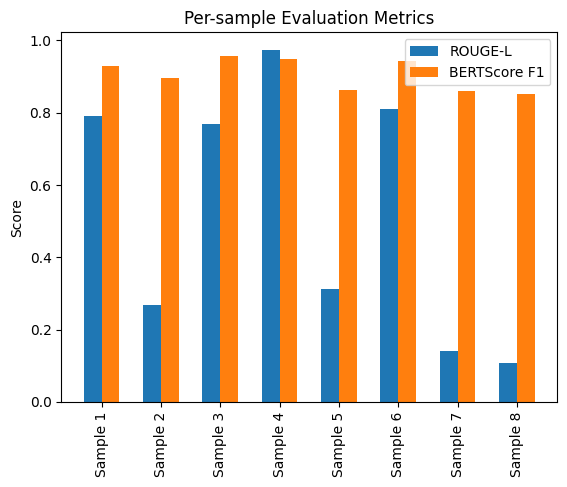

In [ ]:
# ROUGE-L and BERTScore F1
import pandas as pd
from evaluate import load
import matplotlib.pyplot as plt
#Load and Inspect Data
df = pd.read_csv("/content/sample_data/qa_judge_inputs.csv", encoding="latin-1")
df.head()

#Converts the two DataFrame columns prediction and reference into plain Python lists of strings
prediction = df["prediction"].tolist()
reference = df["reference"].tolist()


# Initialize Evaluation Metrics
rouge = load("rouge") #load("rouge") returns an object configured to compute ROUGE scores
bertscore = load("bertscore") #load("bertscore") returns an object for computing BERTScore

# Compute per-sample scores for each row
rows = []
for pred, ref in zip(prediction, reference):
    rouge.add_batch(predictions=[pred], references=[ref])
    bertscore.add_batch(predictions=[pred], references=[ref])
    r = rouge.compute()
    b = bertscore.compute(lang="en")

    rows.append({
        "prediction": pred,
        "reference": ref,
        "rougeL": r["rougeL"],
        "bert_f1": b["f1"][0]
    })

# Create DataFrame and display the scores
df_scores = pd.DataFrame(rows)
display(df_scores)

# Plot side by side bar chart to plot Rouge-L and BERTScore
plt.figure()
x = range(len(df_scores))
plt.bar([i - 0.15 for i in x], df_scores["rougeL"], width=0.3, label="ROUGE-L")
plt.bar([i + 0.15 for i in x], df_scores["bert_f1"], width=0.3, label="BERTScore F1")
plt.xticks(x, [f"Sample {i+1}" for i in x], rotation=90)
plt.ylabel("Score")
plt.legend()
plt.title("Per-sample Evaluation Metrics")
plt.show()


In order to run the LLM-as-Judge, first you need to run the following command below and login into Huggingface manually with your Huggingface API token. As meta-llama/Llama-2-7b-hf model has restricted access.

In [ ]:
!huggingface-cli login


    _|    _|  _|    _|    _|_|_|    _|_|_|  _|_|_|  _|      _|    _|_|_|      _|_|_|_|    _|_|      _|_|_|  _|_|_|_|
    _|    _|  _|    _|  _|        _|          _|    _|_|    _|  _|            _|        _|    _|  _|        _|
    _|_|_|_|  _|    _|  _|  _|_|  _|  _|_|    _|    _|  _|  _|  _|  _|_|      _|_|_|    _|_|_|_|  _|        _|_|_|
    _|    _|  _|    _|  _|    _|  _|    _|    _|    _|    _|_|  _|    _|      _|        _|    _|  _|        _|
    _|    _|    _|_|      _|_|_|    _|_|_|  _|_|_|  _|      _|    _|_|_|      _|        _|    _|    _|_|_|  _|_|_|_|

    To log in, `huggingface_hub` requires a token generated from https://huggingface.co/settings/tokens .
Enter your token (input will not be visible): 
Add token as git credential? (Y/n) Y
Token is valid (permission: read).
The token `token1studio` has been saved to /root/.cache/huggingface/stored_tokens
Cannot authenticate through git-credential as no helper is defined on your machine.
You might have to re-authenticate wh

Next, you need to run the following command below.

In [ ]:
!git config --global credential.helper store

Next, you need to run the following command again.

In [ ]:
!huggingface-cli login


    _|    _|  _|    _|    _|_|_|    _|_|_|  _|_|_|  _|      _|    _|_|_|      _|_|_|_|    _|_|      _|_|_|  _|_|_|_|
    _|    _|  _|    _|  _|        _|          _|    _|_|    _|  _|            _|        _|    _|  _|        _|
    _|_|_|_|  _|    _|  _|  _|_|  _|  _|_|    _|    _|  _|  _|  _|  _|_|      _|_|_|    _|_|_|_|  _|        _|_|_|
    _|    _|  _|    _|  _|    _|  _|    _|    _|    _|    _|_|  _|    _|      _|        _|    _|  _|        _|
    _|    _|    _|_|      _|_|_|    _|_|_|  _|_|_|  _|      _|    _|_|_|      _|        _|    _|    _|_|_|  _|_|_|_|

    A token is already saved on your machine. Run `huggingface-cli whoami` to get more information or `huggingface-cli logout` if you want to log out.
    Setting a new token will erase the existing one.
    To log in, `huggingface_hub` requires a token generated from https://huggingface.co/settings/tokens .
Enter your token (input will not be visible): 
Add token as git credential? (Y/n) Y
Token is valid (permission: read)

LLM-as-Judge

In [ ]:
import json, re, os
import pandas as pd
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    TextGenerationPipeline
)
import torch

#Load the Llama-2-7B model & tokenizer
REPO_ID = "meta-llama/Llama-2-7b-hf"
tokenizer = AutoTokenizer.from_pretrained(REPO_ID, trust_remote_code=True)
#Loads the 7-billion-parameter LLaMA-2 model
model = AutoModelForCausalLM.from_pretrained(
    REPO_ID, device_map="auto", torch_dtype=torch.float16, trust_remote_code=True
)

#Build the Judge Generation Pipeline
judge = TextGenerationPipeline(
    model=model,
    tokenizer=tokenizer,
    do_sample=True,
    temperature=0.2,
    max_new_tokens=64,
)

#llm_as_judge Function Definition
def llm_as_judge(context, question, prediction, reference=None):
    # Build prompt with explicit rubric + example
    prompt = (
        "You are an expert evaluator for question‑answering.\n\n"
        "### Scoring Rubric\n"
        "5 = Exactly correct and precise.\n"
        "4 = Correct but missing minor details or slightly imprecise.\n"
        "3 = Partially correct with some important omissions or small errors.\n"
        "2 = Mostly incorrect but contains a kernel of truth.\n"
        "1 = Completely incorrect.\n\n"
        "### Example  (one‑shot)\n"
        "Context: Water freezes at 0°C under standard pressure.\n"
        "Question: At what temperature does water freeze?\n"
        "Predicted Answer: Water turns to ice at zero degrees Celsius.\n"
        "Reference Answer: 0°C\n"
        "Output: {\"score\": 5, \"reasoning\": \"Exactly correct and precise.\"}\n\n"
        "### Now evaluate\n"
        f"Context: {context}\n"
        f"Question: {question}\n"
        f"Predicted Answer: {prediction}\n"
    )
    if reference:
        prompt += f"Reference Answer: {reference}\n"
    prompt += "Output:"

    # Generate with deterministic decoding
    out = judge(
        prompt,
        max_new_tokens=64,
        do_sample=False,         # <- deterministic
        temperature=0.0,         # <- no randomness
    )[0]["generated_text"]

    # Extract **all** {} JSON blocks from the judge output using regex
    all_json = re.findall(r"\{[^}]*\}", out, re.DOTALL)

    # Parse the **last** one (the model’s evaluation)
    if all_json:
        try:
            return json.loads(all_json[-1])
        except json.JSONDecodeError:
            pass

    # regex extract the score and reasoning
    m1 = re.search(r'"score"\s*:\s*([1-5])', out)
    m2 = re.search(r'"reasoning"\s*:\s*"([^"]+)"', out)
    return {
        "score": int(m1.group(1)) if m1 else None,
        "reasoning": m2.group(1) if m2 else None,
        "raw": out
    }


if __name__ == "__main__":
    #Read CSV file which contains context, question, prediction, and reference
    csv_path = os.environ.get("QA_INPUT_CSV", "/content/sample_data/qa_judge_inputs.csv")
    #Read the CSV file to a dataframe
    df = pd.read_csv(csv_path, encoding="latin-1")

    #Add new columns to the dataframe
    df["score"] = None
    df["reasoning"] = None

    #Loop through the dataframe and get context, question, prediction, and reference for each row and pass to LLM as judge
    for idx, row in df.iterrows():
        verdict = llm_as_judge(
            context=row["context"],
            question=row["question"],
            prediction=row["prediction"],
            reference=row.get("reference"),
        )
        #print result
        print("Judge verdict:", verdict)
        # Add score and resoning to the dataframe
        df.at[idx, "score"] = verdict["score"]
        df.at[idx, "reasoning"] = verdict["reasoning"]

    # Write the df to CSV
    df.to_csv(os.environ.get("QA_OUTPUT_CSV", "qa_judge_results.csv"), index=False)
    print("Saved results.")


tokenizer_config.json:   0%|          | 0.00/776 [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.84M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/609 [00:00<?, ?B/s]

...

model-00001-of-00002.safetensors:   0%|          | 0.00/9.98G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/188 [00:00<?, ?B/s]

Device set to use cuda:0
/usr/local/lib/python3.11/dist-packages/transformers/generation/configuration_utils.py:631: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.0` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/transformers/generation/configuration_utils.py:636: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.9` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(


Judge verdict: {'score': 5, 'reasoning': 'Exactly correct and precise.'}
Judge verdict: {'score': 4, 'reasoning': 'Correct but missing minor details or slightly imprecise.'}
Judge verdict: {'score': 5, 'reasoning': 'Exactly correct and precise.'}
Judge verdict: {'score': 4, 'reasoning': 'Correct but missing minor details or slightly imprecise.'}
Judge verdict: {'score': 4, 'reasoning': 'Correct but missing minor details or slightly imprecise.'}
Judge verdict: {'score': 5, 'reasoning': 'Exactly correct and precise.'}
Judge verdict: {'score': 4, 'reasoning': 'Correct but missing minor details or slightly imprecise.'}
Judge verdict: {'score': 4, 'reasoning': 'Correct but missing minor details or slightly imprecise.'}
Saved results.


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/776 [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.84M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

...

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.11/dist-packages/transformers/generation/configuration_utils.py:631: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.0` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/transformers/generation/configuration_utils.py:636: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.9` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(


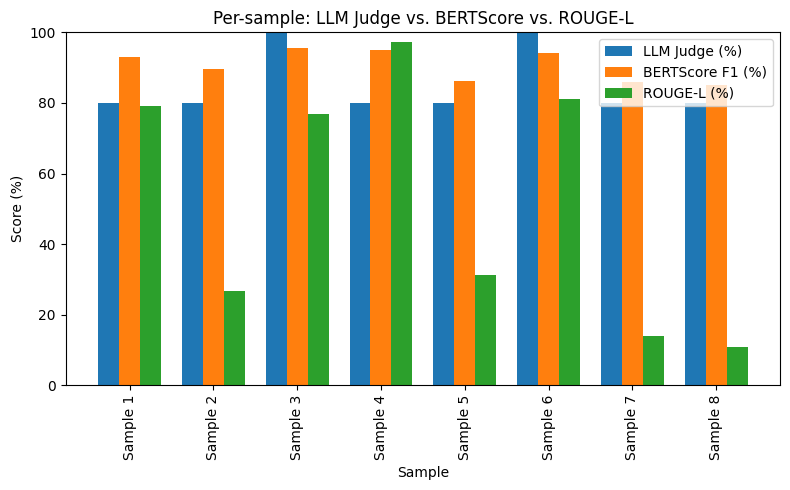

     rougeL   bert_f1  judge_1to5  judge_pct  rougeL_pct  bert_f1_pct
0  0.791667  0.929050           4       80.0   79.166667    92.905015
1  0.267606  0.896337           4       80.0   26.760563    89.633697
2  0.769231  0.956819           5      100.0   76.923077    95.681876
3  0.973822  0.949637           4       80.0   97.382199    94.963706
4  0.313625  0.862250           4       80.0   31.362468    86.225021
5  0.810127  0.942582           5      100.0   81.012658    94.258237
6  0.140162  0.859357           4       80.0   14.016173    85.935682
7  0.108108  0.851129           4       80.0   10.810811    85.112947
Average LLM Judge: 85.00%
Average ROUGE-L: 52.18%
Average BERTScore F1: 90.59%
                                          Prediction  \
0  The three biggest wildfire behavior factors ar...   
1  Prescribed burning is a controlled burn of veg...   
2  Yes, there are wildfire resources for the stat...   
3  Pre-fire: plan\n\tSign up to receive local em...   
4  1.\tPut 

In [ ]:
import os
import re
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from evaluate import load
from transformers import AutoTokenizer, AutoModelForCausalLM, TextGenerationPipeline
import torch

df = pd.read_csv("/content/sample_data/qa_judge_inputs.csv", encoding="latin-1")
df.head()

preds = df["prediction"].tolist()
refs  = df["reference"].tolist()

# ─── 2) INIT METRICS ─────────────────────────────────────────────────────────────
rouge = load("rouge")
bertscore = load("bertscore")

# ─── 3) LLM-AS-JUDGE SETUP ────────────────────────────────────────────────────────
REPO_ID = "meta-llama/Llama-2-7b-hf"
tokenizer = AutoTokenizer.from_pretrained(REPO_ID, trust_remote_code=True)
model = AutoModelForCausalLM.from_pretrained(
    REPO_ID, device_map="auto", torch_dtype=torch.float16, trust_remote_code=True
)
judge = TextGenerationPipeline(
    model=model, tokenizer=tokenizer,
    do_sample=True, temperature=0.2, max_new_tokens=64
)

def llm_as_judge(context, question, prediction, reference=None):
    prompt = (
        "You are an expert evaluator for question-answering.\n\n"
        "### Scoring Rubric\n"
        "5 = Exactly correct and precise.\n"
        "4 = Correct but missing minor details or slightly imprecise.\n"
        "3 = Partially correct with some important omissions or small errors.\n"
        "2 = Mostly incorrect but contains a kernel of truth.\n"
        "1 = Completely incorrect.\n\n"
        "### Example (one-shot)\n"
        "Context: Water freezes at 0°C under standard pressure.\n"
        "Question: At what temperature does water freeze?\n"
        "Predicted Answer: Water turns to ice at zero degrees Celsius.\n"
        "Reference Answer: 0°C\n"
        "Output: {\"score\": 5, \"reasoning\": \"Exactly correct and precise.\"}\n\n"
        "### Now evaluate\n"
        f"Context: {context}\n"
        f"Question: {question}\n"
        f"Predicted Answer: {prediction}\n"
    )
    if reference:
        prompt += f"Reference Answer: {reference}\n"
    prompt += "Output:"

    out = judge(prompt, max_new_tokens=64, do_sample=False, temperature=0.0)[0]["generated_text"]
    all_json = re.findall(r"\{[^}]*\}", out, re.DOTALL)
    if all_json:
        try:
            return json.loads(all_json[-1])
        except json.JSONDecodeError:
            pass
    m1 = re.search(r'"score"\s*:\s*([1-5])', out)
    m2 = re.search(r'"reasoning"\s*:\s*"([^"]+)"', out)
    return {
        "score": int(m1.group(1)) if m1 else None,
        "reasoning": m2.group(1) if m2 else None,
        "raw": out
    }

# ─── 4) COMPUTE ALL SCORES ───────────────────────────────────────────────────────
rows = []
for idx, (pred, ref) in enumerate(zip(preds, refs)):
    # Rouge & BERTScore accumulate internally, so we can call compute once per sample:
    rouge.add_batch(predictions=[pred], references=[ref])
    bertscore.add_batch(predictions=[pred], references=[ref])
    r = rouge.compute()            # dict with keys 'rouge1','rouge2','rougeL'
    b = bertscore.compute(lang="en")  # dict with 'precision','recall','f1' lists

    # LLM-as-judge
    context  = df.at[idx, "context"]
    question = df.at[idx, "question"]
    verdict  = llm_as_judge(context, question, pred, ref)

    rows.append({
        "rougeL":   r["rougeL"],
        "bert_f1":  b["f1"][0],
        "judge_1to5": verdict["score"]
    })

df_scores = pd.DataFrame(rows)

# ─── 5) NORMALIZE TO % ──────────────────────────────────────────────────────────
df_scores["judge_pct"]     = df_scores["judge_1to5"] / 5 * 100
df_scores["rougeL_pct"]    = df_scores["rougeL"]    * 100
df_scores["bert_f1_pct"]   = df_scores["bert_f1"]   * 100

# ─── 6) PLOT SIDE-BY-SIDE BAR CHART ─────────────────────────────────────────────
n = len(df_scores)
x = np.arange(n)
width = 0.25

fig, ax = plt.subplots(figsize=(max(8, n*0.4), 5))
ax.bar(x - width, df_scores["judge_pct"],   width, label="LLM Judge (%)")
ax.bar(x,         df_scores["bert_f1_pct"], width, label="BERTScore F1 (%)")
ax.bar(x + width, df_scores["rougeL_pct"],  width, label="ROUGE-L (%)")

ax.set_xticks(x)
ax.set_xticklabels([f"Sample {i+1}" for i in x], rotation=90)
ax.set_ylim(0, 100)
ax.set_xlabel("Sample")
ax.set_ylabel("Score (%)")
ax.set_title("Per-sample: LLM Judge vs. BERTScore vs. ROUGE-L")
ax.legend()
plt.tight_layout()
plt.show()

print(df_scores)

#Calculate the average of the judge_pct, rougeL_pct, and bert_f1_pct
average_judge_pct = df_scores["judge_pct"].mean()
average_rougeL_pct = df_scores["rougeL_pct"].mean()
average_bert_f1_pct = df_scores["bert_f1_pct"].mean()

#Print the average of the judge_pct, rougeL_pct, bert_f1_pct
print(f"Average LLM Judge: {average_judge_pct:.2f}%")
print(f"Average ROUGE-L: {average_rougeL_pct:.2f}%")
print(f"Average BERTScore F1: {average_bert_f1_pct:.2f}%")

#Generate a table with the prediction, reference with their judge_pct,rougeL_pct, bert_f1_pct
table_data = []
for idx, row in df.iterrows():
    table_data.append([
        row["prediction"],
        row["reference"],
        df_scores.at[idx, "judge_pct"],
        df_scores.at[idx, "rougeL_pct"],
        df_scores.at[idx, "bert_f1_pct"]
    ])
table_df = pd.DataFrame(table_data, columns=["Prediction", "Reference", "LLM Judge (%)", "ROUGE-L (%)", "BERTScore F1 (%)"])
print(table_df)
